# Experiment 2: LSTM with Log Returns

The first LSTM experiment directly predicted absolute stock prices.

Although the model achieved relatively low training and validation errors,
it failed to generalize to the substantially higher price levels observed
in the test period.

In this experiment, the model will predict daily log returns instead of
absolute prices.

## Prediction Task

Input:

`previous 20 daily log returns`

Target:

`next daily log return`

The predicted return will then be converted back into a next-day stock
price using the most recently known price.


In [1]:
from pathlib import Path
import copy
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


## Setup

In [2]:
def get_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


device = get_device()

torch.manual_seed(42)
np.random.seed(42)

print("Device:", device)


Device: mps


In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_directory = project_root / "data"
models_directory = project_root / "models"
results_directory = project_root / "results"

models_directory.mkdir(exist_ok=True)
results_directory.mkdir(exist_ok=True)


## Data Preparation

In [4]:
clean_data_path = (
    data_directory / "aapl_clean.csv"
)

price_df = pd.read_csv(
    clean_data_path,
    parse_dates=["date"],
)

price_df.head()


,date,price,scaled_price
0,2015-01-02 00:00:00-05:00,24.171755,-0.953909
1,2015-01-05 00:00:00-05:00,23.490805,-0.962571
2,2015-01-06 00:00:00-05:00,23.493013,-0.962543
3,2015-01-07 00:00:00-05:00,23.822433,-0.958353
4,2015-01-08 00:00:00-05:00,24.737743,-0.946710


In [5]:
print(price_df.shape)
print(price_df.columns.tolist())

price_df[["date", "price"]].head()


(2766, 3)
['date', 'price', 'scaled_price']


,date,price
0,2015-01-02 00:00:00-05:00,24.171755
1,2015-01-05 00:00:00-05:00,23.490805
2,2015-01-06 00:00:00-05:00,23.493013
3,2015-01-07 00:00:00-05:00,23.822433
4,2015-01-08 00:00:00-05:00,24.737743


In [6]:
return_df = price_df[
    ["date", "price"]
].copy()

return_df["previous_price"] = (
    return_df["price"].shift(1)
)

return_df["log_return"] = np.log(
    return_df["price"]
    / return_df["previous_price"]
)

return_df = (
    return_df
    .dropna()
    .reset_index(drop=True)
)

return_df.head()


,date,price,previous_price,log_return
0,2015-01-05 00:00:00-05:00,23.490805,24.171755,-0.028576
1,2015-01-06 00:00:00-05:00,23.493013,23.490805,0.000094
2,2015-01-07 00:00:00-05:00,23.822433,23.493013,0.013925
3,2015-01-08 00:00:00-05:00,24.737743,23.822433,0.037702
4,2015-01-09 00:00:00-05:00,24.764280,24.737743,0.001072


In [7]:
return_df["log_return"].describe()


count    2765.000000
mean        0.000874
std         0.018154
min        -0.137708
25%        -0.007309
50%         0.000950
75%         0.009965
max         0.142617
Name: log_return, dtype: float64

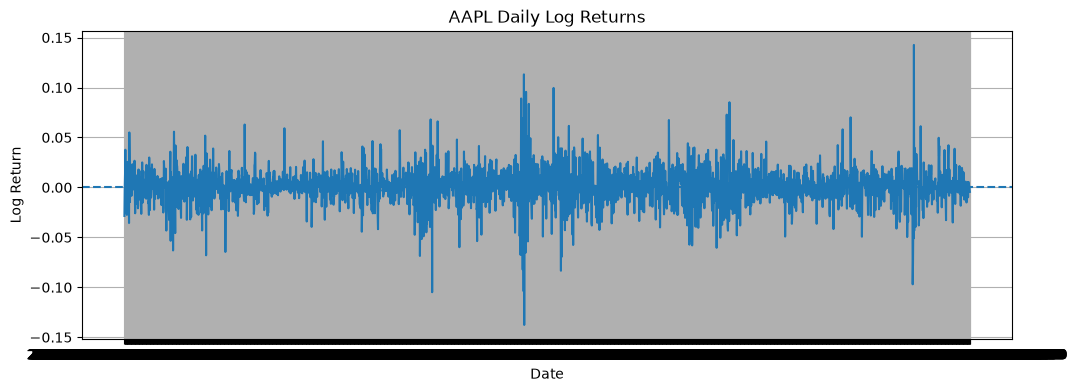

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(
    return_df["date"],
    return_df["log_return"],
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Date")
plt.ylabel("Log Return")
plt.title("AAPL Daily Log Returns")
plt.grid(True)
plt.show()


## Chronological Split and Scaling

In [9]:
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
LOOKBACK = 20
BATCH_SIZE = 32

number_of_rows = len(return_df)

train_end = int(
    number_of_rows * TRAIN_RATIO
)

validation_end = int(
    number_of_rows
    * (TRAIN_RATIO + VALIDATION_RATIO)
)

print("Total:", number_of_rows)
print("Train end:", train_end)
print("Validation end:", validation_end)


Total: 2765
Train end: 1935
Validation end: 2350


In [10]:
train_returns = return_df.iloc[
    :train_end
][["log_return"]]

return_scaler = StandardScaler()

return_scaler.fit(
    train_returns
)

return_df["scaled_return"] = (
    return_scaler.transform(
        return_df[["log_return"]]
    )
    .ravel()
)


In [11]:
print(
    "Train scaled mean:",
    return_df["scaled_return"]
    .iloc[:train_end]
    .mean(),
)

print(
    "Train scaled std:",
    return_df["scaled_return"]
    .iloc[:train_end]
    .std(),
)


Train scaled mean: 3.672055481964342e-18
Train scaled std: 1.0002584981302063


## Sequences

In [12]:
def create_sequences(
    values: np.ndarray,
    lookback: int,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    sequences = []
    targets = []
    target_indices = []

    for target_index in range(
        lookback,
        len(values),
    ):
        start_index = (
            target_index - lookback
        )

        sequence = values[
            start_index:target_index
        ]

        target = values[
            target_index
        ]

        sequences.append(sequence)
        targets.append(target)
        target_indices.append(
            target_index
        )

    X = np.array(
        sequences,
        dtype=np.float32,
    ).reshape(
        -1,
        lookback,
        1,
    )

    y = np.array(
        targets,
        dtype=np.float32,
    ).reshape(
        -1,
        1,
    )

    target_indices = np.array(
        target_indices,
        dtype=np.int64,
    )

    return X, y, target_indices


In [13]:
scaled_returns = return_df[
    "scaled_return"
].to_numpy(
    dtype=np.float32
)

X_all, y_all, target_indices = (
    create_sequences(
        values=scaled_returns,
        lookback=LOOKBACK,
    )
)

print("X:", X_all.shape)
print("y:", y_all.shape)


X: (2745, 20, 1)
y: (2745, 1)


In [14]:
train_mask = (
    target_indices < train_end
)

validation_mask = (
    (target_indices >= train_end)
    & (target_indices < validation_end)
)

test_mask = (
    target_indices >= validation_end
)

X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_validation = X_all[
    validation_mask
]
y_validation = y_all[
    validation_mask
]

X_test = X_all[test_mask]
y_test = y_all[test_mask]


In [15]:
print(
    "Train:",
    X_train.shape,
    y_train.shape,
)

print(
    "Validation:",
    X_validation.shape,
    y_validation.shape,
)

print(
    "Test:",
    X_test.shape,
    y_test.shape,
)


Train: (1915, 20, 1) (1915, 1)
Validation: (415, 20, 1) (415, 1)
Test: (415, 20, 1) (415, 1)


In [16]:
test_target_indices = (
    target_indices[test_mask]
)

test_rows = return_df.iloc[
    test_target_indices
].copy()

test_rows[
    [
        "date",
        "previous_price",
        "price",
        "log_return",
    ]
].head()


,date,previous_price,price,log_return
2350,2024-05-07 00:00:00-04:00,179.750443,180.432968,0.003790
2351,2024-05-08 00:00:00-04:00,180.432968,180.769318,0.001862
2352,2024-05-09 00:00:00-04:00,180.769318,182.579605,0.009965
2353,2024-05-10 00:00:00-04:00,182.579605,181.321564,-0.006914
2354,2024-05-13 00:00:00-04:00,181.321564,184.521072,0.017492


In [17]:
prepared_return_path = (
    data_directory
    / "aapl_returns_prepared.npz"
)

np.savez(
    prepared_return_path,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    X_test=X_test,
    y_test=y_test,
    test_target_indices=test_target_indices,
)

print(
    "Saved:",
    prepared_return_path,
)

return_scaler_path = (
    data_directory
    / "aapl_return_scaler.joblib"
)

joblib.dump(
    return_scaler,
    return_scaler_path,
)


Saved: /Users/omurravli/Desktop/pythorch_stock_predict/data/aapl_returns_prepared.npz


['/Users/omurravli/Desktop/pythorch_stock_predict/data/aapl_return_scaler.joblib']

## Data Loaders

In [18]:
X_train_tensor = torch.from_numpy(
    X_train
)
y_train_tensor = torch.from_numpy(
    y_train
)

X_validation_tensor = torch.from_numpy(
    X_validation
)
y_validation_tensor = torch.from_numpy(
    y_validation
)

X_test_tensor = torch.from_numpy(
    X_test
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


## LSTM Model

In [19]:
class LSTMModel(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1,
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        lstm_output, _ = self.lstm(x)

        last_time_step = (
            lstm_output[:, -1, :]
        )

        prediction = self.output_layer(
            last_time_step
        )

        return prediction


In [20]:
INPUT_SIZE = 1
HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.2

LEARNING_RATE = 0.001
NUMBER_OF_EPOCHS = 100
PATIENCE = 15

model = LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


## Training

In [21]:
training_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

training_start_time = time.perf_counter()

for epoch in range(NUMBER_OF_EPOCHS):
    model.train()

    total_training_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_X)

        loss = loss_function(
            predictions,
            batch_y,
        )

        loss.backward()
        optimizer.step()

        total_training_loss += (
            loss.item()
            * batch_X.size(0)
        )

    average_training_loss = (
        total_training_loss
        / len(train_dataset)
    )

    training_losses.append(
        average_training_loss
    )

    model.eval()

    total_validation_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in validation_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_X)

            validation_loss = loss_function(
                predictions,
                batch_y,
            )

            total_validation_loss += (
                validation_loss.item()
                * batch_X.size(0)
            )

    average_validation_loss = (
        total_validation_loss
        / len(validation_dataset)
    )

    validation_losses.append(
        average_validation_loss
    )

    if (
        average_validation_loss
        < best_validation_loss
    ):
        best_validation_loss = (
            average_validation_loss
        )

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train: {average_training_loss:.6f} | "
            f"Validation: "
            f"{average_validation_loss:.6f}"
        )

    if (
        epochs_without_improvement
        >= PATIENCE
    ):
        print(
            f"Early stopping at epoch "
            f"{epoch + 1}"
        )
        break


Epoch  10 | Train: 0.973717 | Validation: 0.777418
Epoch  20 | Train: 0.944467 | Validation: 0.774804
Epoch  30 | Train: 0.930044 | Validation: 0.777926
Early stopping at epoch 33


In [22]:
training_time = (
    time.perf_counter()
    - training_start_time
)

model.load_state_dict(
    best_model_state
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"Best validation loss: "
    f"{best_validation_loss:.6f}"
)


Training time: 9.16 seconds
Best validation loss: 0.772736


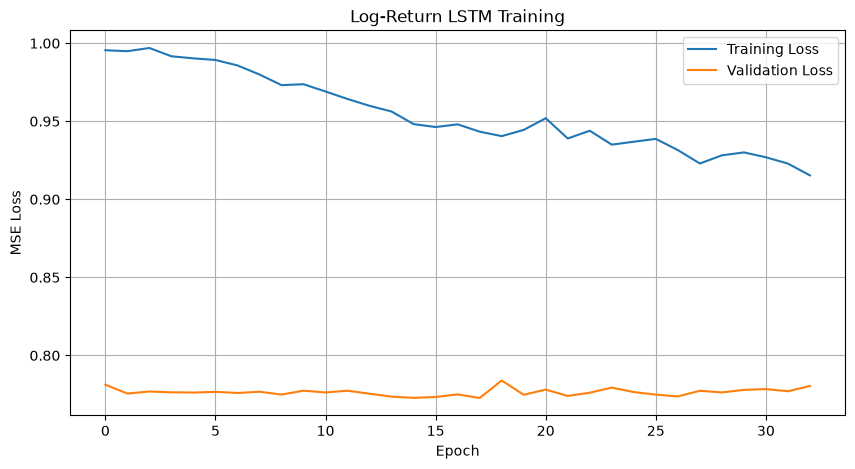

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_losses,
    label="Training Loss",
)

plt.plot(
    validation_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(
    "Log-Return LSTM Training"
)

plt.legend()
plt.grid(True)
plt.show()


## Evaluation

In [24]:
model.eval()

with torch.no_grad():
    predicted_returns_scaled = model(
        X_test_tensor.to(device)
    )

predicted_returns_scaled = (
    predicted_returns_scaled
    .cpu()
    .numpy()
)

predicted_returns = (
    return_scaler.inverse_transform(
        predicted_returns_scaled
    )
    .ravel()
)

actual_returns = (
    return_scaler.inverse_transform(
        y_test
    )
    .ravel()
)


In [25]:
return_mse = mean_squared_error(
    actual_returns,
    predicted_returns,
)

return_rmse = np.sqrt(
    return_mse
)

print(
    f"Return RMSE: "
    f"{return_rmse:.6f}"
)


Return RMSE: 0.017859


In [26]:
previous_prices = (
    test_rows["previous_price"]
    .to_numpy()
)

actual_prices = (
    test_rows["price"]
    .to_numpy()
)

predicted_prices = (
    previous_prices
    * np.exp(predicted_returns)
)

baseline_predictions = (
    previous_prices.copy()
)


In [27]:
lstm_mae = mean_absolute_error(
    actual_prices,
    predicted_prices,
)

lstm_mse = mean_squared_error(
    actual_prices,
    predicted_prices,
)

lstm_rmse = np.sqrt(
    lstm_mse
)

baseline_mae = mean_absolute_error(
    actual_prices,
    baseline_predictions,
)

baseline_mse = mean_squared_error(
    actual_prices,
    baseline_predictions,
)

baseline_rmse = np.sqrt(
    baseline_mse
)


In [28]:
comparison_df = pd.DataFrame({
    "model": [
        "Naive Baseline",
        "Log-Return LSTM",
    ],
    "mae": [
        baseline_mae,
        lstm_mae,
    ],
    "mse": [
        baseline_mse,
        lstm_mse,
    ],
    "rmse": [
        baseline_rmse,
        lstm_rmse,
    ],
})

comparison_df.round(4)


,model,mae,mse,rmse
0,Naive Baseline,2.5887,14.7321,3.8382
1,Log-Return LSTM,2.5820,14.6314,3.8251


In [29]:
actual_direction = np.sign(
    actual_returns
)

predicted_direction = np.sign(
    predicted_returns
)

direction_accuracy = np.mean(
    actual_direction
    == predicted_direction
) * 100

print(
    f"Direction Accuracy: "
    f"{direction_accuracy:.2f}%"
)


Direction Accuracy: 53.98%


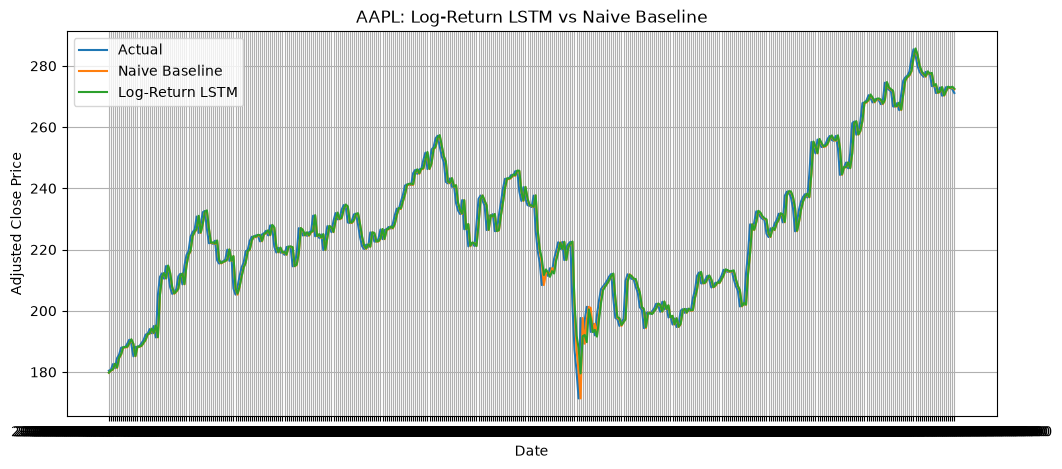

In [30]:
test_dates = (
    test_rows["date"]
    .to_numpy()
)

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_prices,
    label="Actual",
)

plt.plot(
    test_dates,
    baseline_predictions,
    label="Naive Baseline",
)

plt.plot(
    test_dates,
    predicted_prices,
    label="Log-Return LSTM",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.title(
    "AAPL: Log-Return LSTM "
    "vs Naive Baseline"
)

plt.legend()
plt.grid(True)

comparison_plot_path = (
    results_directory
    / "lstm_log_return_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## Save Results

In [31]:
results_df = pd.DataFrame({
    "date": test_dates,
    "previous_price": previous_prices,
    "actual_price": actual_prices,
    "actual_return": actual_returns,
    "predicted_return": predicted_returns,
    "baseline_price": baseline_predictions,
    "predicted_price": predicted_prices,
})

results_path = (
    results_directory
    / "lstm_log_return_predictions.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)


In [32]:
metrics_df = pd.DataFrame({
    "model": [
        "Log-Return LSTM"
    ],
    "mae": [
        lstm_mae
    ],
    "mse": [
        lstm_mse
    ],
    "rmse": [
        lstm_rmse
    ],
    "return_rmse": [
        return_rmse
    ],
    "direction_accuracy_pct": [
        direction_accuracy
    ],
    "training_time_seconds": [
        training_time
    ],
})

metrics_df


,model,mae,mse,rmse,return_rmse,direction_accuracy_pct,training_time_seconds
0,Log-Return LSTM,2.581986,14.631363,3.825097,0.017859,53.975904,9.163661


In [33]:
metrics_path = (
    results_directory
    / "lstm_log_return_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False,
)

model_path = (
    models_directory
    / "aapl_lstm_log_return.pth"
)

torch.save(
    model.state_dict(),
    model_path,
)

print("Saved:", results_path)
print("Saved:", metrics_path)
print("Saved:", comparison_plot_path)
print("Saved:", model_path)


Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/lstm_log_return_predictions.csv
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/lstm_log_return_metrics.csv
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/lstm_log_return_comparison.png
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/models/aapl_lstm_log_return.pth
